Вы аналитик оператора сотовой связи. Клиентам предлагают два тарифных плана: «Смарт» и «Ультра». Вам предстоит сделать предварительный анализ тарифов на небольшой выборке клиентов. В вашем распоряжении данные 500 пользователей.
Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.


Шаг 1. Откройте файл с данными и изучите общую информацию.

Шаг 2. Подготовьте данные

    Приведите данные к нужным типам;
    Найдите и исправьте ошибки в данных, если они есть.
    Поясните, какие ошибки вы нашли и как их исправили.
    В данных вы найдёте звонки с нулевой продолжительностью. Это не ошибка: нулями обозначены пропущенные звонки, поэтому их не нужно удалять.

Посчитайте для каждого пользователя:

    количество сделанных звонков и израсходованных минут разговора по месяцам;
    количество отправленных сообщений по месяцам;
    объем израсходованного интернет-трафика по месяцам;
    помесячную выручку с каждого пользователя

Постройте графики для более наглядной демонстрации.



# Описание данных

Таблица users (информация о пользователях):

- user_id — уникальный идентификатор пользователя
- first_name — имя пользователя
- last_name — фамилия пользователя
- age — возраст пользователя (годы)
- reg_date — дата подключения тарифа (день, месяц, год)
- churn_date — дата прекращения пользования тарифом (если значение пропущено, то тариф ещё действовал на момент выгрузки данных)
- city — город проживания пользователя
- tarif — название тарифного плана


Таблица calls (информация о звонках):

- id — уникальный номер звонка
- call_date — дата звонка
- duration — длительность звонка в минутах
- user_id — идентификатор пользователя, сделавшего звонок


Таблица messages (информация о сообщениях):

- id — уникальный номер сообщения
- message_date — дата сообщения
- user_id — идентификатор пользователя, отправившего сообщение


Таблица internet (информация об интернет-сессиях):

- id — уникальный номер сессии
- mb_used — объём потраченного за сессию интернет-трафика (в мегабайтах)
- session_date — дата интернет-сессии
- user_id — идентификатор пользователя


Таблица tariffs (информация о тарифах):

- tariff_name — название тарифа
- rub_monthly_fee — ежемесячная абонентская плата в рублях
- minutes_included — количество минут разговора в месяц, включённых в абонентскую плату
- messages_included — количество сообщений в месяц, включённых в абонентскую плату
- mb_per_month_included — объём интернет-трафика, включённого в абонентскую плату (в мегабайтах)
- rub_per_minute — стоимость минуты разговора сверх тарифного пакета (например, если в тарифе 100 минут разговора в месяц, то со 101 минуты будет взиматься плата)
- rub_per_message — стоимость отправки сообщения сверх тарифного пакета
- rub_per_gb — стоимость дополнительного гигабайта интернет-трафика сверх тарифного пакета (1 гигабайт = 1024 мегабайта)



# Конечный результат эта сводная таблица с данными по использованным услугам всех абонентов по месячно

In [41]:
#импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import copy

In [42]:
#подключение таблиц
calls_df = pd.read_csv(r'.\CSV\calls.csv')
internet_df = pd.read_csv(r'.\CSV\internet.csv')
messeges_df = pd.read_csv(r'.\CSV\messages.csv')
tariffs_df = pd.read_csv(r'.\CSV\tariffs.csv')
users_df = pd.read_csv(r'.\CSV\users.csv')


In [43]:
# проверка на Nan
print(calls_df.isna())
print(internet_df.isna())
print(messeges_df.isna())
print(tariffs_df.isna())
print(users_df.isna())

           id  call_date  duration  user_id
0       False      False     False    False
1       False      False     False    False
2       False      False     False    False
3       False      False     False    False
4       False      False     False    False
...       ...        ...       ...      ...
202602  False      False     False    False
202603  False      False     False    False
202604  False      False     False    False
202605  False      False     False    False
202606  False      False     False    False

[202607 rows x 4 columns]
        Unnamed: 0     id  mb_used  session_date  user_id
0            False  False    False         False    False
1            False  False    False         False    False
2            False  False    False         False    False
3            False  False    False         False    False
4            False  False    False         False    False
...            ...    ...      ...           ...      ...
149391       False  False    False     

In [44]:
#  удаляем ненужный столбец
internet_df = internet_df.drop(columns=['Unnamed: 0'])

In [45]:
users_df

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra
...,...,...,...,...,...,...,...,...
495,1495,65,NaN,Иркутск,Авксентий,Фокин,2018-08-28,ultra
496,1496,36,NaN,Вологда,Трифон,Блохин,2018-01-27,smart
497,1497,32,NaN,Челябинск,Каролина,Агеева,2018-10-09,smart
498,1498,68,2018-10-25,Владикавказ,Всеволод,Акимчин,2018-07-19,smart


в таблице users_df есть nan значения, но я думаю их можно оставить

In [46]:
tariffs_df

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [47]:
calls_df

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000
...,...,...,...,...
202602,1499_215,2018-12-26,0.76,1499
202603,1499_216,2018-10-18,18.83,1499
202604,1499_217,2018-11-10,10.81,1499
202605,1499_218,2018-10-06,4.27,1499


Посчитайте для каждого пользователя:

    количество сделанных звонков и израсходованных минут разговора по месяцам;
    количество отправленных сообщений по месяцам;
    объем израсходованного интернет-трафика по месяцам;
    помесячную выручку с каждого пользователя

In [48]:
# создадим таблицу всех звонков и кто их делал
customers_calls_df = pd.merge(users_df, calls_df, left_on='user_id', right_on='user_id')
customers_calls_df['call_date'] = pd.to_datetime(customers_calls_df['call_date'])

customers_calls_m_df = customers_calls_df
customers_calls_m_df['month'] = customers_calls_df['call_date'].dt.to_period('M')

# статистика по месяцам
monthly_stats = customers_calls_m_df.groupby(['user_id', 'month'])['duration'].agg(['count', 'sum']).reset_index()
monthly_stats = monthly_stats.rename(columns={'count': 'number_of_calls', 'sum': 'total_m_duration'})
monthly_stats['number_of_calls'] = monthly_stats['number_of_calls'].fillna(0)
monthly_stats['total_m_duration'] = monthly_stats['total_m_duration'].fillna(0)

print(monthly_stats)


total_user_stats_df = customers_calls_df.groupby(['user_id','tariff'])['duration'].agg(['count', 'median','sum']).reset_index()
total_user_stats_df = total_user_stats_df.rename(columns={'count': 'number_of_calls', 'median' : 'median_duration', 'sum': 'total_duration'})
total_user_stats_df.sort_values(by='total_duration', ascending=False)


      user_id    month  number_of_calls  total_m_duration
0        1000  2018-05               22            150.06
1        1000  2018-06               43            158.90
2        1000  2018-07               47            318.80
3        1000  2018-08               52            389.87
4        1000  2018-09               58            440.14
...       ...      ...              ...               ...
3169     1498  2018-10               41            232.63
3170     1499  2018-09                9             64.65
3171     1499  2018-10               68            429.91
3172     1499  2018-11               74            576.50
3173     1499  2018-12               69            465.16

[3174 rows x 4 columns]


,user_id,tariff,number_of_calls,median_duration,total_duration
371,1377,ultra,1760,6.240,12258.20
165,1168,ultra,1692,6.040,11624.25
369,1375,ultra,1560,6.155,10757.17
447,1453,ultra,1440,5.895,9711.35
193,1196,ultra,1240,5.775,8204.08
...,...,...,...,...,...
138,1141,smart,36,4.580,198.01
436,1442,ultra,28,5.275,180.33
367,1373,smart,24,5.460,130.16
16,1016,ultra,20,5.155,114.84


In [49]:
monthly_stats

,user_id,month,number_of_calls,total_m_duration
0,1000,2018-05,22,150.06
1,1000,2018-06,43,158.90
2,1000,2018-07,47,318.80
3,1000,2018-08,52,389.87
4,1000,2018-09,58,440.14
...,...,...,...,...
3169,1498,2018-10,41,232.63
3170,1499,2018-09,9,64.65
3171,1499,2018-10,68,429.91
3172,1499,2018-11,74,576.50


In [50]:
# таблица использования пользователями звонков и сообщений по месцам
customers_message_df = pd.merge(users_df, messeges_df, left_on='user_id', right_on='user_id')
customers_message_df['message_date'] = pd.to_datetime(customers_message_df['message_date'])

customers_message_m_df = customers_message_df
customers_message_m_df['month'] = customers_message_df['message_date'].dt.to_period('M')

monthly_stats_mess = customers_message_df.groupby(['user_id', 'month'])['id'].agg(['count']).reset_index()
monthly_stats_mess = monthly_stats_mess.rename(columns={'count': 'number_of_messages'})
monthly_stats_mess['number_of_messages'] = monthly_stats_mess['number_of_messages'].fillna(0)
monthly_stats = pd.merge(monthly_stats, monthly_stats_mess, on=['user_id', 'month'], how='left')

print(monthly_stats)
# общие значения для кждого человека
message_stats = customers_message_df.groupby('user_id')['message_date'].agg(['count']).reset_index()
message_stats = message_stats.rename(columns={'count': 'number_of_messages'})

total_user_stats_df = pd.merge(total_user_stats_df, message_stats, on='user_id', how='left')
total_user_stats_df

      user_id    month  number_of_calls  total_m_duration  number_of_messages
0        1000  2018-05               22            150.06                22.0
1        1000  2018-06               43            158.90                60.0
2        1000  2018-07               47            318.80                75.0
3        1000  2018-08               52            389.87                81.0
4        1000  2018-09               58            440.14                57.0
...       ...      ...              ...               ...                 ...
3169     1498  2018-10               41            232.63                42.0
3170     1499  2018-09                9             64.65                11.0
3171     1499  2018-10               68            429.91                48.0
3172     1499  2018-11               74            576.50                59.0
3173     1499  2018-12               69            465.16                66.0

[3174 rows x 5 columns]


,user_id,tariff,number_of_calls,median_duration,total_duration,number_of_messages
0,1000,ultra,368,5.81,2418.24,496.0
1,1001,smart,122,5.62,799.46,NaN
2,1002,smart,217,5.21,1431.17,70.0
3,1003,ultra,520,5.92,3600.52,380.0
4,1004,ultra,176,3.78,921.21,1192.0
...,...,...,...,...,...,...
487,1495,ultra,565,5.79,3688.57,340.0
488,1496,smart,828,5.92,5661.37,468.0
489,1497,smart,201,6.21,1324.68,51.0
490,1498,smart,180,6.14,1221.60,168.0


In [51]:
monthly_stats_mess

,user_id,month,number_of_messages
0,1000,2018-05,22
1,1000,2018-06,60
2,1000,2018-07,75
3,1000,2018-08,81
4,1000,2018-09,57
...,...,...,...
2712,1498,2018-10,42
2713,1499,2018-09,11
2714,1499,2018-10,48
2715,1499,2018-11,59


In [52]:
# с использованием интернета
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

customers_internet_m_df = internet_df
customers_internet_m_df['month'] = internet_df['session_date'].dt.to_period('M')

monthly_stats_internet = customers_internet_m_df.groupby(['user_id', 'month'])['mb_used'].agg(['count','sum']).reset_index()
monthly_stats_internet = monthly_stats_internet.rename(columns={'count': 'count_of_internet_sessions', 'sum': 'total_used_mb_per_m'})
monthly_stats_internet['count_of_internet_sessions'] = monthly_stats_internet['count_of_internet_sessions'].fillna(0)
monthly_stats = pd.merge(monthly_stats, monthly_stats_internet, on=['user_id', 'month'], how='left')

print(monthly_stats)
print(monthly_stats_internet)

internet_stats = internet_df.groupby('user_id')['mb_used'].agg(['sum']).reset_index()
internet_stats = internet_stats.rename(columns={'sum': 'total_used_mb'})

total_user_stats_df = pd.merge(total_user_stats_df, internet_stats, on='user_id', how='left')
total_user_stats_df['total_used_mb'] = total_user_stats_df['total_used_mb'].fillna(0)
total_user_stats_df['number_of_messages'] = total_user_stats_df['number_of_messages'].fillna(0)
total_user_stats_df['number_of_calls'] = total_user_stats_df['number_of_calls'].fillna(0)
total_user_stats_df['median_duration'] = total_user_stats_df['median_duration'].fillna(0)
total_user_stats_df['total_duration'] = total_user_stats_df['total_duration'].fillna(0)
total_user_stats_df.sort_values(by='total_used_mb', ascending=False)

      user_id    month  number_of_calls  total_m_duration  number_of_messages  \
0        1000  2018-05               22            150.06                22.0   
1        1000  2018-06               43            158.90                60.0   
2        1000  2018-07               47            318.80                75.0   
3        1000  2018-08               52            389.87                81.0   
4        1000  2018-09               58            440.14                57.0   
...       ...      ...              ...               ...                 ...   
3169     1498  2018-10               41            232.63                42.0   
3170     1499  2018-09                9             64.65                11.0   
3171     1499  2018-10               68            429.91                48.0   
3172     1499  2018-11               74            576.50                59.0   
3173     1499  2018-12               69            465.16                66.0   

      count_of_internet_ses

,user_id,tariff,number_of_calls,median_duration,total_duration,number_of_messages,total_used_mb
379,1385,ultra,564,5.685,3727.35,1380.0,376397.38
236,1240,ultra,572,6.555,3918.82,0.0,376237.47
177,1180,ultra,143,5.240,891.49,198.0,348211.20
182,1185,ultra,972,6.165,6731.53,0.0,343533.71
325,1330,ultra,968,6.080,6671.90,803.0,336373.28
...,...,...,...,...,...,...,...
69,1069,smart,45,6.410,329.13,56.0,11348.27
62,1062,smart,83,7.780,662.75,26.0,11072.78
189,1192,ultra,140,6.775,996.75,35.0,9031.84
393,1399,ultra,84,6.525,605.73,130.0,4603.52


In [53]:
# посчитаем сверхприбыль от каждого человека, кто использует больше тарифа. Прибыль по каждой категории
monthly_stats = pd.merge(monthly_stats, users_df[['user_id', 'tariff']], on='user_id', how='left')

In [54]:
monthly_stats = pd.merge(monthly_stats, tariffs_df, left_on='tariff', right_on='tariff_name', how='left')


In [55]:

def calculate_monthly_profit(row):
    monthly_fee = row['rub_monthly_fee']

    # доп заработок на смс
    messages_over = max(0, row['number_of_messages'] - row['messages_included'])
    sms_profit = messages_over * row['rub_per_message']

    #доп заработк на интернете
    mb_used = row['total_used_mb_per_m']
    mb_included = row['mb_per_month_included']
    gb_over = math.ceil(max(0, mb_used - mb_included)/1024)
    internet_profit = gb_over * row['rub_per_gb']

    #доп заработок на звонках
    minutes_used = row['total_m_duration']
    minutes_included = row['minutes_included']
    minutes_over = max(0, minutes_used - minutes_included)
    call_profit = minutes_over * row['rub_per_minute']


    return monthly_fee + sms_profit + internet_profit + call_profit


monthly_stats_test = monthly_stats.copy()

monthly_fee = monthly_stats_test['rub_monthly_fee']


# Функция для расчета доп. заработка
def calculate_extra_profit(row):
    # доп. заработок на смс
    messages_over = max(0, row['number_of_messages'] - row['messages_included'])
    sms_profit = messages_over * row['rub_per_message']

    # доп. заработок на интернете
    mb_used = row['total_used_mb_per_m']
    mb_included = row['mb_per_month_included']
    gb_over = math.ceil(max(0, mb_used - mb_included) / 1024)
    internet_profit = gb_over * row['rub_per_gb']

    # доп. заработок на звонках
    minutes_used = row['total_m_duration']
    minutes_included = row['minutes_included']
    minutes_over = max(0, minutes_used - minutes_included)
    call_profit = minutes_over * row['rub_per_minute']

    return pd.Series([messages_over, sms_profit, gb_over, internet_profit, minutes_over, call_profit])


# Применяем функцию к каждой строке DataFrame
monthly_stats_test[['sms_over', 'sms_profit', 'gb_over', 'internet_profit', 'minutes_over', 'call_profit']] = monthly_stats_test.apply(calculate_extra_profit, axis=1)
monthly_stats_test


monthly_stats['monthly_profit'] = monthly_stats.apply(calculate_monthly_profit, axis=1)
print(monthly_stats[['user_id','month','monthly_profit']].sample(10))

      user_id    month  monthly_profit
558      1089  2018-04         1950.00
1557     1249  2018-12          750.00
806      1127  2018-09          819.00
1676     1269  2018-08          550.00
2303     1370  2018-08         1350.00
2638     1415  2018-12         1950.00
49       1006  2018-09          750.00
1659     1266  2018-10         1950.00
2511     1395  2018-10         1918.72
393      1063  2018-05         1950.00


In [56]:
monthly_stats_test

,user_id,month,number_of_calls,total_m_duration,number_of_messages,count_of_internet_sessions,total_used_mb_per_m,tariff,messages_included,mb_per_month_included,...,rub_per_gb,rub_per_message,rub_per_minute,tariff_name,sms_over,sms_profit,gb_over,internet_profit,minutes_over,call_profit
0,1000,2018-05,22,150.06,22.0,5.0,2253.49,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
1,1000,2018-06,43,158.90,60.0,49.0,23233.77,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
2,1000,2018-07,47,318.80,75.0,29.0,14003.64,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
3,1000,2018-08,52,389.87,81.0,29.0,14055.93,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
4,1000,2018-09,58,440.14,57.0,27.0,14568.91,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3169,1498,2018-10,41,232.63,42.0,59.0,20579.36,smart,50,15360,...,200,3,3,smart,0.0,0.0,6.0,1200.0,0.0,0.0
3170,1499,2018-09,9,64.65,11.0,5.0,1845.75,smart,50,15360,...,200,3,3,smart,0.0,0.0,0.0,0.0,0.0,0.0
3171,1499,2018-10,68,429.91,48.0,58.0,17788.51,smart,50,15360,...,200,3,3,smart,0.0,0.0,3.0,600.0,0.0,0.0
3172,1499,2018-11,74,576.50,59.0,49.0,17963.31,smart,50,15360,...,200,3,3,smart,9.0,27.0,3.0,600.0,76.5,229.5


In [57]:
monthly_stats_total = monthly_stats[['user_id', 'monthly_profit']].groupby('user_id').sum().reset_index()
monthly_stats_total = monthly_stats_total.rename(columns={'monthly_profit':'total_profit'})
print(monthly_stats_total)

     user_id  total_profit
0       1000      15600.00
1       1001       1700.00
2       1002       7250.00
3       1003       9750.00
4       1004      15600.00
..       ...           ...
487     1495      11550.00
488     1496      27690.55
489     1497       2695.99
490     1498       6636.00
491     1499       3704.50

[492 rows x 2 columns]


d:\downloads_from_web\Anaconda\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


     user_id  total_profit  cluster
0       1000      15600.00        2
1       1001       1700.00        0
2       1002       7250.00        0
3       1003       9750.00        2
4       1004      15600.00        2
..       ...           ...      ...
487     1495      11550.00        2
488     1496      27690.55        1
489     1497       2695.99        0
490     1498       6636.00        0
491     1499       3704.50        0

[492 rows x 3 columns]
9687.010203252032


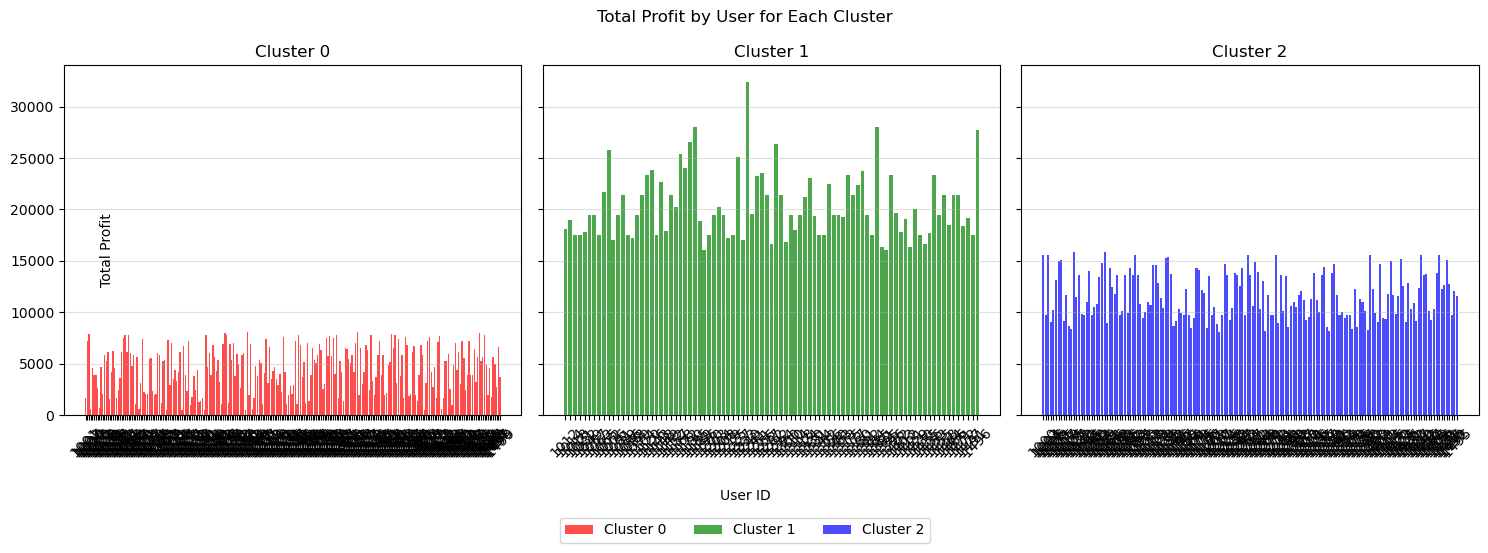

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#кластеризуем
data_for_clustering = monthly_stats_total[['total_profit']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)


# число кластеров
n_clusters = 3 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init argument is very important, see documentation for more details
monthly_stats_total['cluster'] = kmeans.fit_predict(scaled_data)



print(monthly_stats_total)
print(monthly_stats_total['total_profit'].mean())

# строим график
fig, axes = plt.subplots(1, n_clusters, figsize=(15, 5), sharey=True)  # Create subplots, share y-axis

colors = ['red', 'green', 'blue']

for cluster_num in range(n_clusters):
    cluster_data = monthly_stats_total[monthly_stats_total['cluster'] == cluster_num]
    ax = axes[cluster_num] 
    ax.bar(
        cluster_data['user_id'].astype(str),
        cluster_data['total_profit'],
        color = colors[cluster_num],
        alpha=0.7,
        label = f'Cluster {cluster_num}'
    )
    ax.set_title(f'Cluster {cluster_num}')
    ax.tick_params(axis='x', rotation=45, labelrotation = 45)
    ax.grid(axis='y', alpha=0.4)

# значения
fig.text(0.5, 0.00, 'User ID', ha='center')  
fig.text(0.07, 0.5, 'Total Profit', va='center', rotation='vertical') 
fig.suptitle('Total Profit by User for Each Cluster')
fig.legend(loc = 'lower center', ncols = n_clusters, bbox_to_anchor = (0.5, -0.1))
plt.tight_layout(rect = (0, 0.05, 1, 1)) 

plt.show()


In [59]:
# посчитаем, сколько людей не заходят за тариф на постоянной основе
cluster_counts = monthly_stats_total.groupby('cluster').size().reset_index(name='count')

print(cluster_counts)

smart_profit_users = monthly_stats_total[
    (monthly_stats_total['total_profit'] == 1650) |
    (monthly_stats_total['total_profit'] == 550) |
    (monthly_stats_total['total_profit'] == 1100)
]


print(f"количество людей, которые используют тариф smart и не выходят за рамки: {len(smart_profit_users)}")
print(smart_profit_users)

ultra_profit_users = monthly_stats_total[
    (monthly_stats_total['total_profit'] == 1950) |
    (monthly_stats_total['total_profit'] == 3900) |
    (monthly_stats_total['total_profit'] == 5850)
]


print(f"количество людей, которые используют тариф smart и не выходят за рамки: {len(ultra_profit_users)}")
print(ultra_profit_users)

   cluster  count
0        0    242
1        1     87
2        2    163
количество людей, которые используют тариф smart и не выходят за рамки: 14
     user_id  total_profit  cluster
37      1037        1650.0        0
62      1062        1100.0        0
102     1103         550.0        0
115     1117         550.0        0
138     1141         550.0        0
160     1163        1100.0        0
187     1190         550.0        0
192     1195        1650.0        0
203     1206        1100.0        0
228     1232        1100.0        0
238     1242        1100.0        0
289     1293        1650.0        0
400     1406         550.0        0
416     1422        1650.0        0
количество людей, которые используют тариф smart и не выходят за рамки: 25
     user_id  total_profit  cluster
13      1013        3900.0        0
16      1016        3900.0        0
28      1028        5850.0        0
60      1060        5850.0        0
84      1084        1950.0        0
90      1090        58

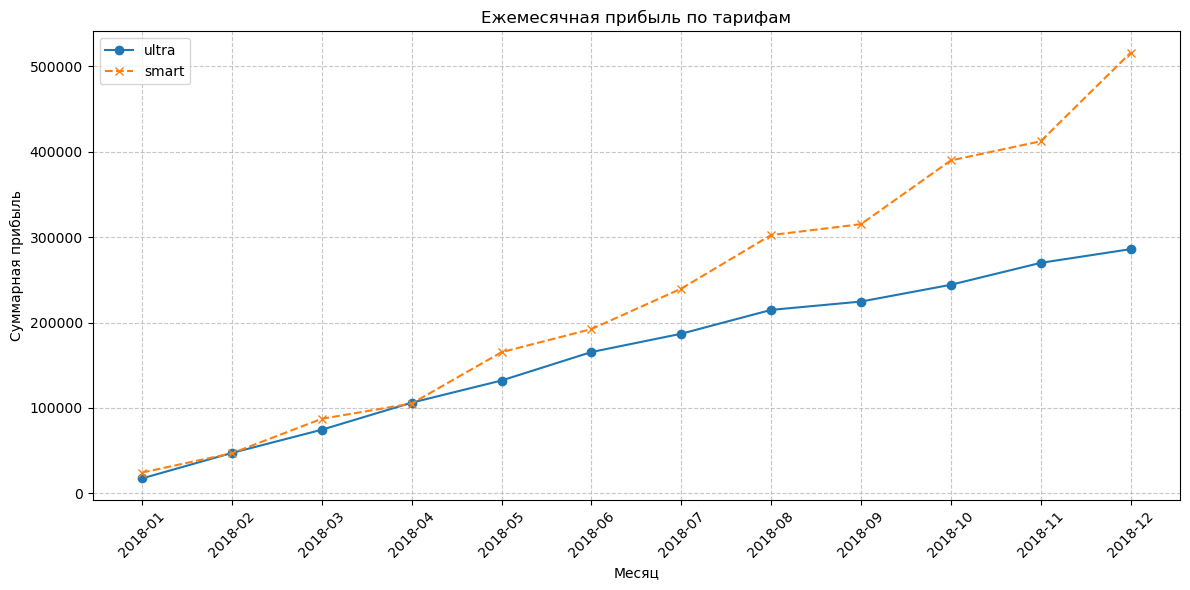

In [60]:
import matplotlib.dates as mdates



# 2. Группировка по месяцу и тарифу и расчет суммарной прибыли
monthly_profit = monthly_stats.groupby(['month', 'tariff'])['monthly_profit'].sum().reset_index()


# 3. Разделение данных на ultra и smart
ultra_profit = monthly_profit[monthly_profit['tariff'] == 'ultra']
smart_profit = monthly_profit[monthly_profit['tariff'] == 'smart']


# 4. Настройка графика
plt.figure(figsize=(12, 6))

# 5. Преобразование 'month' из Period в datetime (для графиков) и построение линий для ultra и smart
plt.plot(ultra_profit['month'].astype(str), ultra_profit['monthly_profit'], marker='o', linestyle='-', label='ultra')
plt.plot(smart_profit['month'].astype(str), smart_profit['monthly_profit'], marker='x', linestyle='--', label='smart')



# 7. Настройка графика
plt.title('Ежемесячная прибыль по тарифам')
plt.xlabel('Месяц')
plt.ylabel('Суммарная прибыль')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
#вычислить, хватает ли людям тарифа. на сколько процетов больше используют интернета, сообщений,
#  звонков на каких тарифах и на каких кластерах ну и сколько в среднем люди из разных кластеров и тарифов переплачивают
# цель - определить, нужен ли новый тариф
# посчитать прирост пользователей каждого тарифа по месяцам с января. кластеризовать пользователей по сообщениям, интернету и смс, предложить варианты
# сколько в среднем от тарифа используют

monthly_stats_test
monthly_stats_profit = monthly_stats_test.groupby(['month', 'tariff'])[['internet_profit','call_profit','sms_profit']].sum().reset_index()
monthly_stats_profit['total_profit'] = monthly_stats_profit['internet_profit'] + monthly_stats_profit['call_profit']+ monthly_stats_profit['sms_profit']
monthly_stats_profit


,month,tariff,internet_profit,call_profit,sms_profit,total_profit
0,2018-01,smart,5600.0,83.85,72.0,5755.85
1,2018-01,ultra,0.0,0.00,0.0,0.00
2,2018-02,smart,13200.0,1617.45,321.0,15138.45
3,2018-02,ultra,600.0,0.00,0.0,600.00
4,2018-03,smart,38200.0,5651.52,1158.0,45009.52
5,2018-03,ultra,2400.0,0.00,0.0,2400.00
6,2018-04,smart,36000.0,6376.35,1233.0,43609.35
7,2018-04,ultra,2850.0,0.00,0.0,2850.00
8,2018-05,smart,77400.0,8077.44,2262.0,87739.44
9,2018-05,ultra,7350.0,0.00,0.0,7350.00


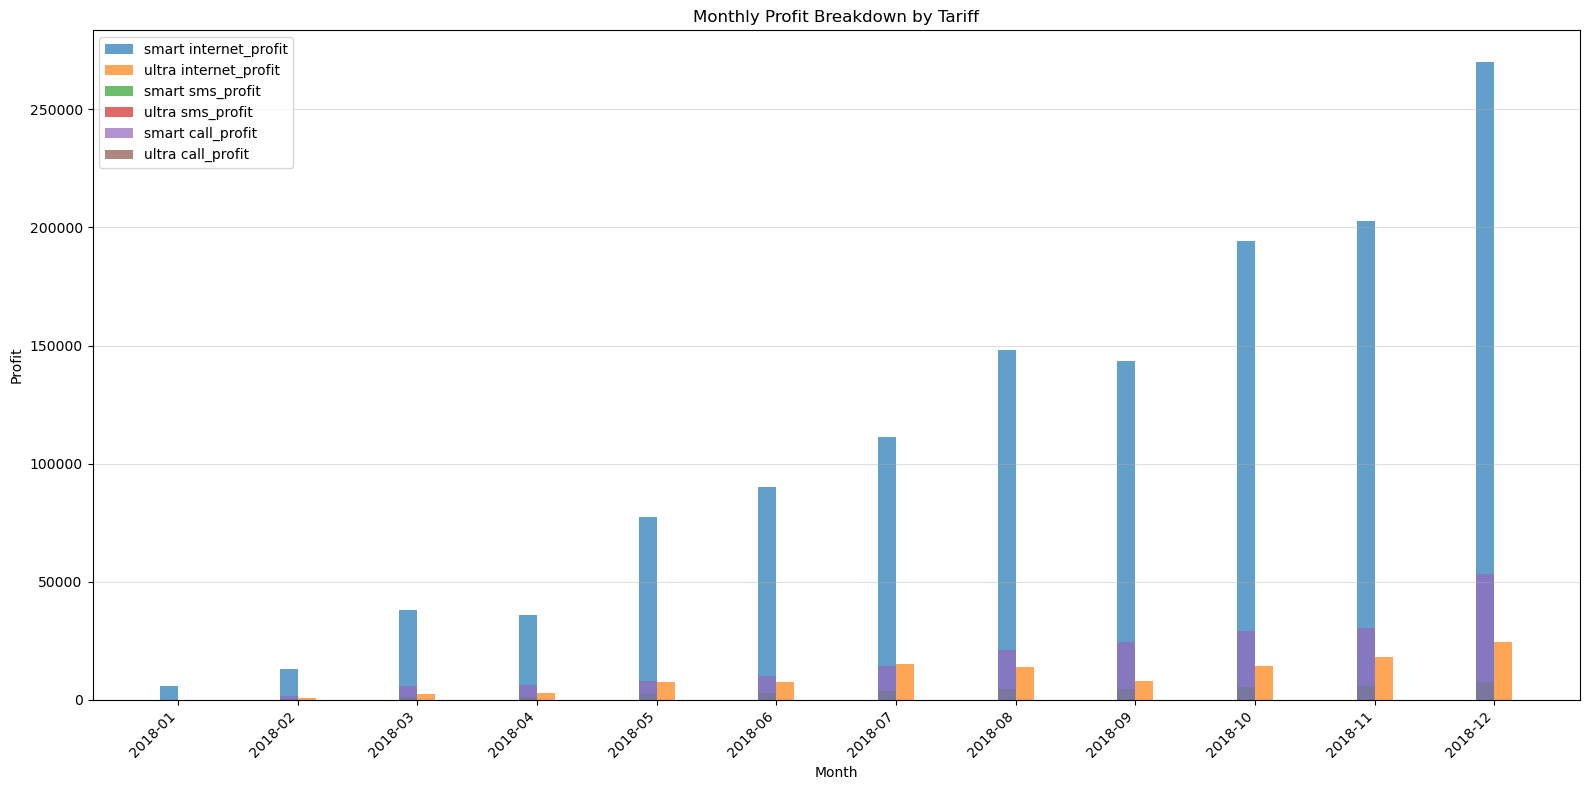

In [62]:
# Виды получки
profits = ['internet_profit', 'sms_profit', 'call_profit']
tariff_values = monthly_stats_profit['tariff'].unique()
# Построение графика
fig, ax = plt.subplots(figsize=(16, 8))
bar_width = 0.15 
x = np.arange(len(monthly_stats_profit)/2) 

# получаем тип заработа и строим столб сколько
for i, profit in enumerate(profits):
    for j, tariff in enumerate(tariff_values):
        profit_values = monthly_stats_profit.loc[monthly_stats_profit['tariff'] == tariff].sort_values(by='month')[profit].values
        x_positions = x - bar_width/2 + j * bar_width
        ax.bar(x_positions, profit_values, width=bar_width, label=f'{tariff} {profit}', align='center', alpha = 0.7)


# названия
ax.set_xlabel('Month')
ax.set_ylabel('Profit')
ax.set_title('Monthly Profit Breakdown by Tariff')
ax.set_xticks(x) # Set x axis ticks
ax.set_xticklabels([month.strftime('%Y-%m') for month in monthly_stats_profit['month'].unique()], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.grid(axis='y', alpha = 0.4)
plt.show()

In [63]:
print('Таблица сколько пользуются тарифом')
users_monthly = monthly_stats_test.groupby(['month', 'tariff'])['user_id'].count().reset_index()
users_monthly

Таблица сколько пользуются тарифом


,month,tariff,user_id
0,2018-01,smart,34
1,2018-01,ultra,9
2,2018-02,smart,58
3,2018-02,ultra,24
4,2018-03,smart,77
5,2018-03,ultra,37
6,2018-04,smart,112
7,2018-04,ultra,53
8,2018-05,smart,141
9,2018-05,ultra,64


In [64]:
mean_stats_month  = monthly_stats_test.groupby(['tariff','month'])[['internet_profit', 'minutes_over', 'call_profit']].mean().reset_index()
smart_mean_stats_month = mean_stats_month.groupby(['tariff']).mean()
del smart_mean_stats_month['month']
smart_mean_stats_month

,internet_profit,minutes_over,call_profit
tariff,,,
smart,513.383771,24.769459,74.308376
ultra,98.190198,0.000000,0.000000


In [65]:
#сколько процентов от тарифа используют люди в среднем по человеку и в общем

# тест
monthly_stats_test_percent = monthly_stats_test.copy()
 
# Функция для расчета доп. заработка
def calculate_percent(row):
    # доп. заработок на смс
    messages_over = max(0, row['number_of_messages'] - row['messages_included'])
    sms_profit = messages_over * row['rub_per_message']

    # доп. заработок на интернете
    mb_used = row['total_used_mb_per_m']
    mb_included = row['mb_per_month_included']
    gb_over = math.ceil(max(0, mb_used - mb_included) / 1024)
    internet_profit = gb_over * row['rub_per_gb']

    # доп. заработок на звонках
    minutes_used = row['total_m_duration']
    minutes_included = row['minutes_included']
    minutes_over = max(0, minutes_used - minutes_included)
    call_profit = minutes_over * row['rub_per_minute']

    return pd.Series([messages_over, sms_profit, gb_over, internet_profit, minutes_over, call_profit])


# Применяем функцию к каждой строке DataFrame
monthly_stats_test[['sms_over', 'sms_profit', 'gb_over', 'internet_profit', 'minutes_over', 'call_profit']] = monthly_stats_test.apply(calculate_extra_profit, axis=1)
monthly_stats_test



,user_id,month,number_of_calls,total_m_duration,number_of_messages,count_of_internet_sessions,total_used_mb_per_m,tariff,messages_included,mb_per_month_included,...,rub_per_gb,rub_per_message,rub_per_minute,tariff_name,sms_over,sms_profit,gb_over,internet_profit,minutes_over,call_profit
0,1000,2018-05,22,150.06,22.0,5.0,2253.49,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
1,1000,2018-06,43,158.90,60.0,49.0,23233.77,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
2,1000,2018-07,47,318.80,75.0,29.0,14003.64,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
3,1000,2018-08,52,389.87,81.0,29.0,14055.93,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
4,1000,2018-09,58,440.14,57.0,27.0,14568.91,ultra,1000,30720,...,150,1,1,ultra,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3169,1498,2018-10,41,232.63,42.0,59.0,20579.36,smart,50,15360,...,200,3,3,smart,0.0,0.0,6.0,1200.0,0.0,0.0
3170,1499,2018-09,9,64.65,11.0,5.0,1845.75,smart,50,15360,...,200,3,3,smart,0.0,0.0,0.0,0.0,0.0,0.0
3171,1499,2018-10,68,429.91,48.0,58.0,17788.51,smart,50,15360,...,200,3,3,smart,0.0,0.0,3.0,600.0,0.0,0.0
3172,1499,2018-11,74,576.50,59.0,49.0,17963.31,smart,50,15360,...,200,3,3,smart,9.0,27.0,3.0,600.0,76.5,229.5


графики медианной по месяцам и линии

график количества аудитории

график получки

вычислить прирост аудитории в процентах

график темпов роста по кадому тарифу и в целом 


In [66]:
#agr
users_monthly


,month,tariff,user_id
0,2018-01,smart,34
1,2018-01,ultra,9
2,2018-02,smart,58
3,2018-02,ultra,24
4,2018-03,smart,77
5,2018-03,ultra,37
6,2018-04,smart,112
7,2018-04,ultra,53
8,2018-05,smart,141
9,2018-05,ultra,64


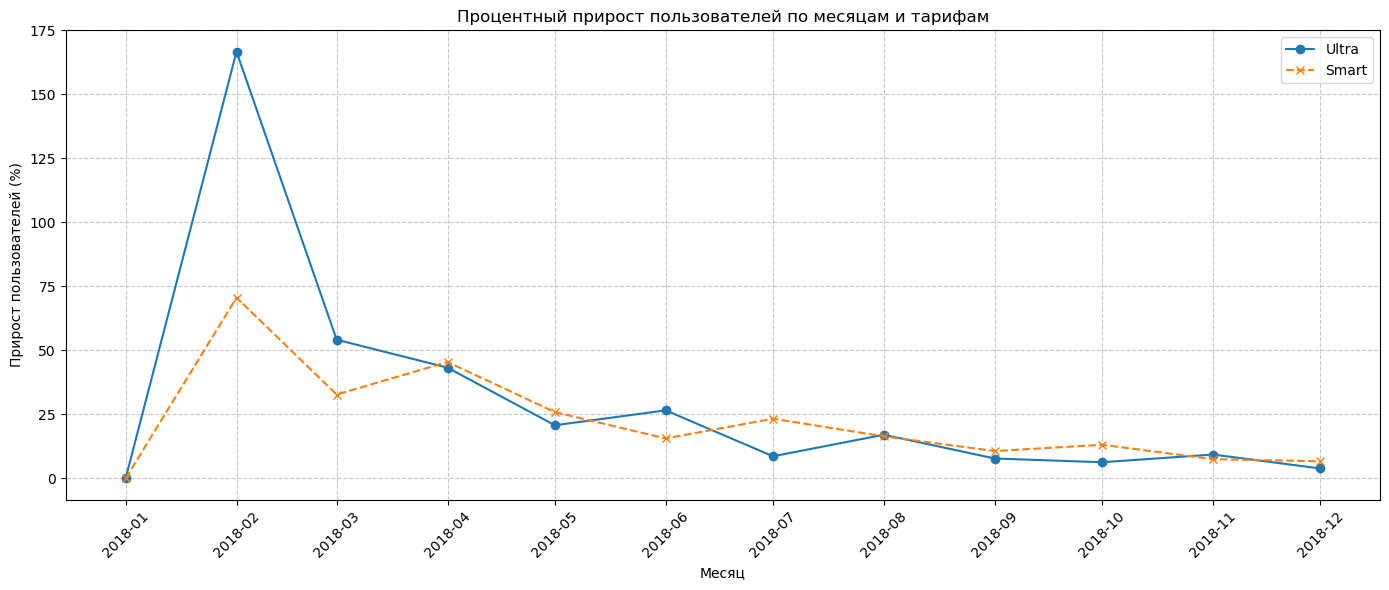

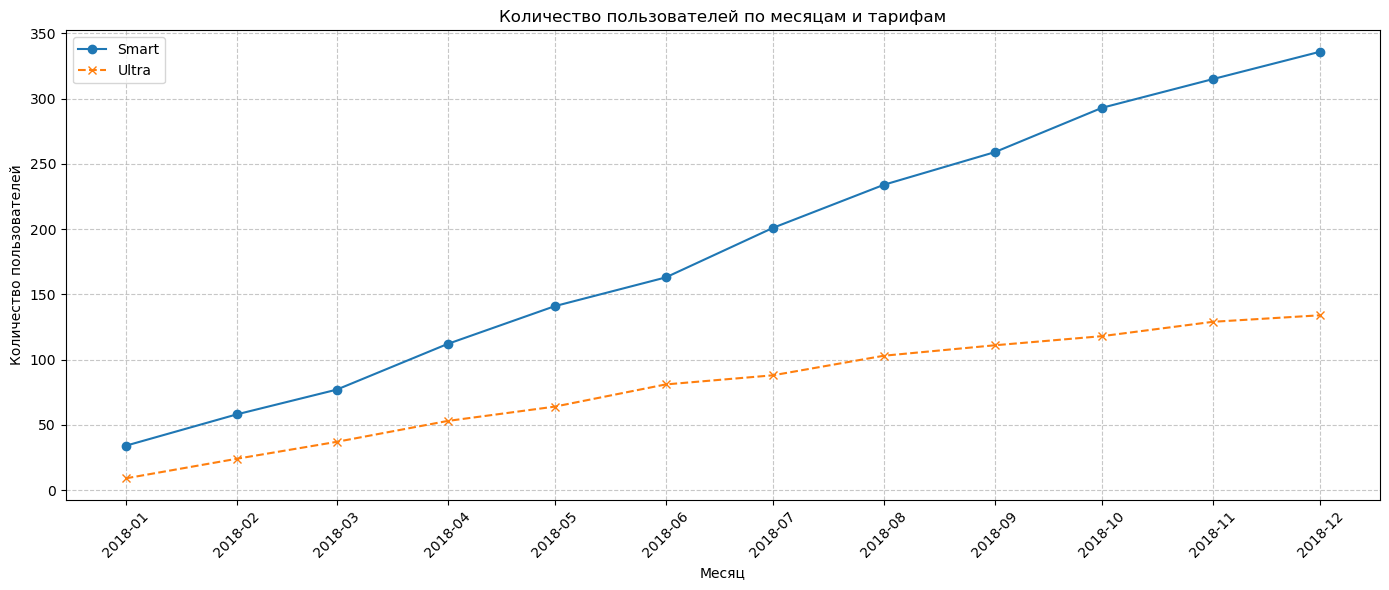

In [67]:
# Группировка по месяцу и тарифу
monthly_users = users_monthly.groupby(['month', 'tariff'])['user_id'].sum().reset_index()

# Расчет процентного прироста
monthly_users['prev_month_users'] = monthly_users.groupby('tariff')['user_id'].shift(1)
monthly_users['growth_rate'] = ((monthly_users['user_id'] - monthly_users['prev_month_users']) / monthly_users['prev_month_users']) * 100
monthly_users.fillna(0, inplace=True)

# Разделяем данные по тарифам для графиков
ultra_growth = monthly_users[monthly_users['tariff'] == 'ultra'].copy()
smart_growth = monthly_users[monthly_users['tariff'] == 'smart'].copy()

# --- Процентный прирост ---
plt.figure(figsize=(14, 6))
plt.plot(ultra_growth['month'].apply(lambda x: x.to_timestamp()), ultra_growth['growth_rate'], marker='o', linestyle='-', label='Ultra')
plt.plot(smart_growth['month'].apply(lambda x: x.to_timestamp()), smart_growth['growth_rate'], marker='x', linestyle='--', label='Smart')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title('Процентный прирост пользователей по месяцам и тарифам')
plt.xlabel('Месяц')
plt.ylabel('Прирост пользователей (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# --- Абсолютное количество пользователей ---
plt.figure(figsize=(14, 6))
plt.plot(smart_growth['month'].apply(lambda x: x.to_timestamp()), smart_growth['user_id'], marker='o', linestyle='-', label='Smart')
plt.plot(ultra_growth['month'].apply(lambda x: x.to_timestamp()), ultra_growth['user_id'], marker='x', linestyle='--', label='Ultra')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.title('Количество пользователей по месяцам и тарифам')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Выводы

людям из смарт тарифа не хватает интернета и в среднем переплата по 500 у.е. и им легче пользоваться смарт тарифом, чем ультра тарифом.

отдельно заработок за интернет или связь больше, чем стоимость за весь тариф ультра

те кто пользуется ультра тарифом зачастую не выходят за рамки использования

можно сделать дополнительный тариф, где будет много звонков, либо тариф, где много интернета